In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
print("All essential libraries imported successfully!")

D:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


TensorFlow Version: 2.21.0
All essential libraries imported successfully!


In [22]:
# Configuration parameters

IMG_SIZE = 150
BASE_DIR = "SkinDisease"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

def load_skin_data(folder_path):
    images, labels = [], []
    categories = sorted(os.listdir(folder_path))
    
    for idx, cat in enumerate(categories):
        sub_folder = os.path.join(folder_path, cat)
        if os.path.isdir(sub_folder):
            print(f"Loading: {cat}")
            for img_name in os.listdir(sub_folder):
                img = cv2.imread(os.path.join(sub_folder, img_name))
                if img is not None:
                    images.append(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))
                    labels.append(idx)
                    
    return np.array(images), np.array(labels), categories

# Main data loader execution
X_train, y_train, class_names = load_skin_data(TRAIN_DIR)
X_test, y_test, _ = load_skin_data(TEST_DIR)

NUM_CLASSES = len(class_names)
print(f"Done! Classes count: {NUM_CLASSES}")

Loading: Acne
Loading: Eczema
Loading: Psoriasis
Loading: Unknown_Normal
Loading: Vitiligo
Loading: Acne
Loading: Eczema
Loading: Psoriasis
Loading: Unknown_Normal
Loading: Vitiligo
Done! Classes count: 5


In [23]:
# Convert pixel values to float and scale them between 0 and 1 (Normalization)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert integer class labels to one-hot encoded binary matrix format
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
print("Data scaling and categorical encoding finished successfully!")

Train shapes: X=(4788, 150, 150, 3), y=(4788, 5)
Test shapes: X=(536, 150, 150, 3), y=(536, 5)
Data scaling and categorical encoding finished successfully!


In [24]:
# Initialize a simple and explicit sequential CNN architecture
model = Sequential([
    # First Convolutional Layer to capture basic image textures and edges
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), name='target_conv'),
    MaxPooling2D((2, 2)),
    
    # Second Convolutional Layer to extract higher-level skin features
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flattening 2D feature maps into a 1D vector for dense layers
    Flatten(),
    
    # Fully Connected Network for pattern mapping and classification
    Dense(128, activation='relu'),
    Dropout(0.5),  # Prevents model overfitting during the training cycle
    Dense(NUM_CLASSES, activation='softmax')  # Output layer computing probabilities
])

# Compile the created model configuration
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ target_conv (Conv2D)            │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,636,997 (40.58 MB)

 Trainable params: 10,636,997 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the model network over a direct and safe limit of epochs
print("Initializing model training pipeline...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)
print("Model training execution completed!")

Initializing model training pipeline...
Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 493ms/step - accuracy: 0.4695 - loss: 1.4302 - val_accuracy: 0.5448 - val_loss: 1.0063
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 85s 567ms/step - accuracy: 0.5781 - loss: 1.0163 - val_accuracy: 0.5560 - val_loss: 0.9833
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 126s 460ms/step - accuracy: 0.6351 - loss: 0.8849 - val_accuracy: 0.6231 - val_loss: 0.9057
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 487ms/step - accuracy: 0.6957 - loss: 0.7481 - val_accuracy: 0.6810 - val_loss: 0.8411
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 515ms/step - accuracy: 0.7529 - loss: 0.6158 - val_accuracy: 0.6828 - val_loss: 0.8511
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 484ms/step - accuracy: 0.7980 - loss: 0.5123 - val_accuracy: 0.6642 - val_loss: 0.8691
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 487ms/step - accuracy: 0.8204 - loss: 0.4478 - val_accuracy: 0.6772 - val_loss: 0.9478
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 74

In [27]:
# Evaluate and print in one go
test_loss, test_acc = model.evaluate(X_test, y_test)
print(
    "Test Accuracy:",
    test_acc
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6996 - loss: 1.1463
Test Accuracy: 0.6996268630027771


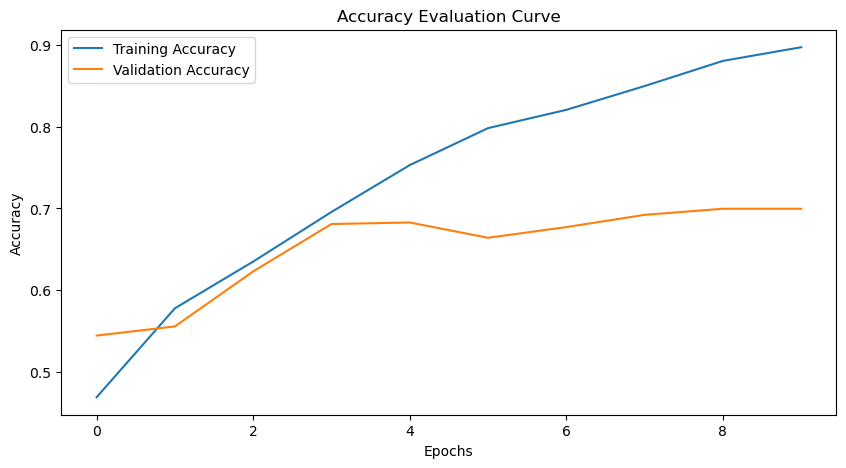

In [30]:
# 1. Plot Model Accuracy and Evaluation Loss Curves
plt.figure(figsize=(10, 5))


plt.plot(
    history.history['accuracy'], 
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'], 
    label='Validation Accuracy'
)
plt.title(
    'Accuracy Evaluation Curve'
)
plt.xlabel(
    'Epochs'
)
plt.ylabel(
    'Accuracy'
)
plt.legend()

plt.show()

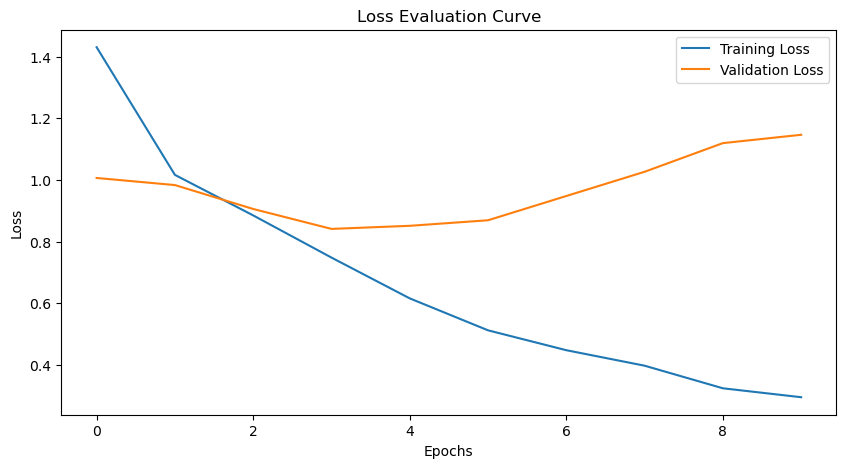

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], 
         label='Training Loss')
plt.plot(history.history['val_loss'], 
         label='Validation Loss')

plt.title(
    'Loss Evaluation Curve'
)

plt.xlabel(
    'Epochs'
)
plt.ylabel(
    'Loss'
)

plt.legend()

plt.show()

In [33]:
# 2. Compute Predictions and Display Classification Metrics Report
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred, axis=1
)
y_true_classes = np.argmax(
    y_test, axis=1
)

print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_true_classes,
        y_pred_classes, 
        target_names=class_names
    )
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step

=== DETAILED CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

          Acne       0.67      0.48      0.56        65
        Eczema       0.67      0.61      0.64       112
     Psoriasis       0.53      0.72      0.61        88
Unknown_Normal       0.89      0.82      0.85       189
      Vitiligo       0.62      0.71      0.66        82

      accuracy                           0.70       536
     macro avg       0.67      0.67      0.66       536
  weighted avg       0.72      0.70      0.70       536



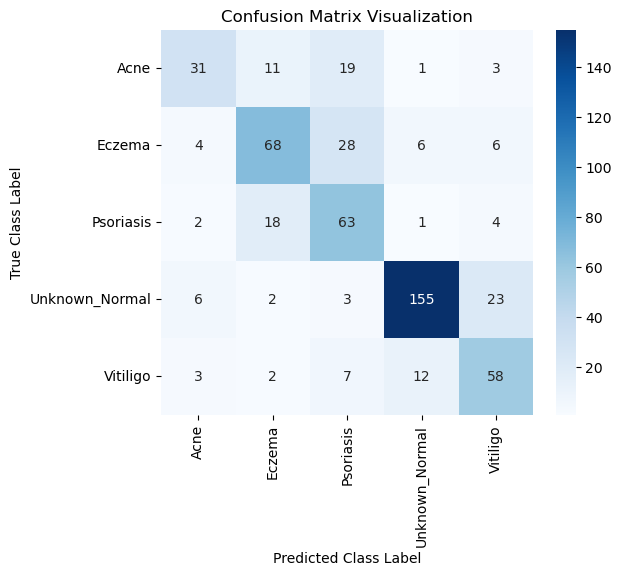

In [34]:
# 3. Generate and Render Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(
    y_true_classes, 
    y_pred_classes
)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    xticklabels=class_names, 
    yticklabels=class_names, 
    cmap='Blues'
)
plt.title(
    'Confusion Matrix Visualization'
)
plt.ylabel(
    'True Class Label'
)
plt.xlabel(
    'Predicted Class Label'
)
plt.show()

In [35]:
# Save the trained model to your computer
model.save("skin_disease_model.keras")
print("Model saved successfully as skin_disease_model.keras!")

Model saved successfully as skin_disease_model.keras!


In [36]:
# Load the saved model anytime without retraining
model = tf.keras.models.load_model("skin_disease_model.keras")
print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


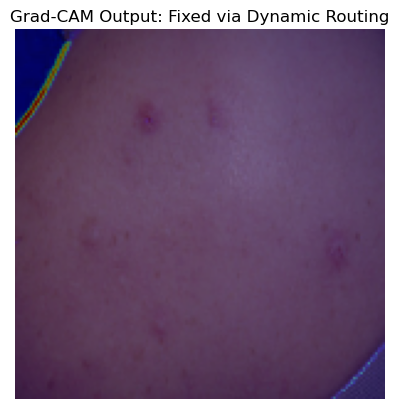

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_gradcam_heatmap(img_array, model):
    # Find the first Conv2D layer in the loaded model architecture
    conv_layer = None
    for layer in model.layers:
        if 'conv' in layer.name.lower():
            conv_layer = layer
            break
            
    if conv_layer is None:
        raise ValueError("Model mein koi Convolutional layer nahi mili!")

    # Define a pure functional model using the layers configuration directly
    input_shape = model.input_shape[1:] if model.input_shape else (150, 150, 3)
    inputs = tf.keras.Input(shape=input_shape)
    
    # Re-route layers execution dynamically
    x = inputs
    target_output = None
    for layer in model.layers:
        x = layer(x)
        if layer == conv_layer:
            target_output = x
            
    # Create the standalone gradient tracking framework
    grad_model = Model(inputs=inputs, outputs=[target_output, x])
    
    # Compute gradients with respect to the extracted layer
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        highest_probability_class = tf.argmax(predictions[0])
        class_loss_value = predictions[:, highest_probability_class]

    # Calculate weights and generate heatmaps
    gradients = tape.gradient(class_loss_value, conv_outputs)
    global_pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ global_pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Apply ReLU and normalize the heatmap values
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Run Grad-CAM visualization safely
if len(X_test) > 0:
    sample_img = X_test[0]
    sample_batch = np.expand_dims(sample_img, axis=0)
    
    # Execute the robust gradient tracker
    heatmap_output = generate_gradcam_heatmap(sample_batch, model)
    
    # Resize and apply color map overlay over original image
    heatmap_resized = cv2.resize(heatmap_output, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    blended_output = cv2.addWeighted(np.uint8(sample_img * 255), 0.6, heatmap_colored, 0.4, 0)
    
    # Render final result
    plt.imshow(cv2.cvtColor(blended_output, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Output: Fixed via Dynamic Routing")
    plt.axis('off')
    plt.show()

In [41]:
# Save Grad-CAM image to current directory
plt.imsave("gradcam_result.png", cv2.cvtColor(blended_output, cv2.COLOR_BGR2RGB))
print("Grad-CAM Output image saved as 'gradcam_result.png'!")

Grad-CAM Output image saved as 'gradcam_result.png'!


In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ target_conv (Conv2D)            │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,910,993 (121.73 MB)

 Trainable params: 10,636,997 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,273,996 (81.15 MB)